- High Resolution Image (rasterized): $x$ -- length $N$
- Low Resolution Images (rasterized): $y^{(k)}$ -- length $M$. Total of $K$ 

In [1]:
import numpy as np
from PIL import Image

# Setup

## Download HR image

In [2]:
hr_size = [200, 200] # rows x cols

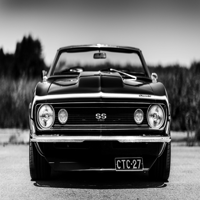

In [3]:
hr_img = Image.open("../imgs/hr.jpg")
hr_img = hr_img.resize(hr_size[::-1]) # invert b/c this takes in width/height not rows/cols
hr_img

## Create LR images

In [4]:
shift_range = [-2, 2]
rot_range = [-4, 4] # degrees
downsample_ratio = 4
gamma = 2.0
beta = 400

In [8]:
def create_lr_image(
        hr_img: Image, 
        downsample_ratio: int,
        shift_range: list[float],
        rot_range: list[float],
        gamma: float,
        beta: float) -> np.ndarray:
    
    """
    Given a High Resolution image and some parameters, produces a single low-resolution image array

    HR = indexed by i
    LR = indexed by j
    """

    # 1. Get all pixel locations in LR & HR
    hr_size = np.array(np.array(hr_img).shape[:2])              
    lr_size = (hr_size / downsample_ratio).astype(dtype=np.int64)

    v_i = np.argwhere(np.ones(hr_size)).T # (2, N)
    v_avg = np.mean(v_i, axis = 1, keepdims = True)

    v_j_unscaled = np.argwhere(np.ones(lr_size)).T
    # convert from lr coordinates -> hr coordinates  w/ [0,0] fixed   
    # the offset term is so that each LR pixel corresponds to the center of an HR patch 
    v_j = v_j_unscaled * downsample_ratio + (downsample_ratio - 1) / 2.0 

    # 2. Sample Random Shift & Sample
    shift = np.random.uniform(*shift_range, size = (2, 1))
    rot = np.deg2rad(np.random.uniform(*rot_range))

    # 3. Perform Transformation: u_j = R(rot) @ (v - v_avg) + v_avg + shift [rotating around the CENTER, not (0,0)]
    R = np.array([[np.cos(rot), np.sin(rot)], [-np.sin(rot), np.cos(rot)]])  
    u_j = R @ (v_j - v_avg) + v_avg + shift # (2, M)

    # 4. Create Point-Spread Function (v_i vs. u_j)
    v_i_t = v_i.T  # (N, 2)
    u_j_t = u_j.T  # (M, 2)
    
    # squared norms
    vi_sq = np.sum(v_i_t**2, axis=1, keepdims=True)   # (N, 1)
    vj_sq = np.sum(u_j_t**2, axis=1)   # (M,)

    # ||a-b||^2 = ||a||^2 + ||b||^2 - 2 * a * b
    dists_sq = vi_sq + vj_sq - 2 * v_i_t @ u_j_t.T # (N, M)

    W = np.exp(-dists_sq / (gamma**2)).T  # (M, N)
    W = W / np.sum(W, axis = -1, keepdims=True)

    # 5. Get new LR image
    eps = np.random.normal(0, np.sqrt(1 / beta), size = (np.prod(lr_size), 1))

    hr_rasterized = np.array(hr_img)[:, :, 0].flatten()[:, None]
    print(hr_rasterized.min(), hr_rasterized.max())
    hr_rasterized = (hr_rasterized / 255.0) - 0.5 # normalize to the range [-0.5, 0.5]

    y = W @ hr_rasterized + eps
    return y


In [9]:
lr = create_lr_image(hr_img, downsample_ratio, shift_range, rot_range, gamma, beta)
print(lr.shape)
# display_ready = np.clip(255 * (lr + 0.5), 0, 255).astype(np.uint8)
# Image.fromarray(display_ready).show()

0 255
(2500, 1)


In [7]:
print(lr.shape)

(50, 50)


# Solving

## MAP Approach